# Energy Storage Analytics

This notebook analyses the technical characteristics of 25 battery storage units connected across a power grid.

We will:
- Load and merge storage data from two datasets
- Compute the energy capacity of each unit
- Analyse performance by bus and efficiency
- Visualise the results

**Key formula:** `Energy Capacity (kWh) = Power Capability (kW) × Duration (hours)`

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

In [58]:

# Load Sheet 1 — storage unit characteristics
df1 = pd.read_excel("data/stordata_capacity_vlookup.xlsx", sheet_name="Sheet1", usecols=[0,1,2,3])


df1.head()


,id,bus,Efficiency,duration
0,stor1,bus_3,0.76,4.0
1,stor2,bus_3,0.87,1.0
2,stor3,bus_3,0.85,0.5
3,stor4,bus_2,0.89,4.0
4,stor5,bus_2,0.87,3.0


In [59]:

# Load Sheet 2 — power capability
df2 = pd.read_excel("data/stordata_capacity_vlookup.xlsx", sheet_name="Sheet2", usecols=[1,2])

df2.set_index("id", inplace=True)
df2.head()

,power capability
id,
stor16,25
stor3,18
stor6,38
stor5,5
stor7,34


## Step 1: Merge the Datasets
We have two separate tables, first storage characteristics (Sheet 1) and power capability (Sheet 2). 
We merge them using `.map()` which is the Python equivalent of Excel's VLOOKUP.

In [60]:
# Map power capability from df2 into df1 using storage unit id as the key
df1["power capability"] = df1["id"].map(df2["power capability"])

df1.head()

,id,bus,Efficiency,duration,power capability
0,stor1,bus_3,0.76,4.0,8.0
1,stor2,bus_3,0.87,1.0,5.0
2,stor3,bus_3,0.85,0.5,18.0
3,stor4,bus_2,0.89,4.0,12.0
4,stor5,bus_2,0.87,3.0,5.0


## Step 2: Compute Energy Capacity
Using the key formula:

**Energy Capacity (kWh) = Power Capability (kW) × Duration (hours)**

In [61]:
# Compute energy capacity for each storage unit
df1["energy capacity (kWh)"] = df1["power capability"] * df1["duration"]

df1.head()

,id,bus,Efficiency,duration,power capability,energy capacity (kWh)
0,stor1,bus_3,0.76,4.0,8.0,32.0
1,stor2,bus_3,0.87,1.0,5.0,5.0
2,stor3,bus_3,0.85,0.5,18.0,9.0
3,stor4,bus_2,0.89,4.0,12.0,48.0
4,stor5,bus_2,0.87,3.0,5.0,15.0


## Step 3: Analysis
Exploring the data to answer three questions:
1. Which bus has the highest total energy capacity?
2. Which storage unit has the highest energy capacity?
3. What is the average efficiency per bus?
4. Which bus has the highest total energy capacity?

### Question 1 — What is the total energy capacity by bus?

In [67]:

# Question 1 — What is the total energy capacity by bus?
# display as simple html table
total_by_bus = df1.groupby("bus")["energy capacity (kWh)"].sum().sort_values(ascending=False)
print("Total Energy Capacity by Bus (kWh):")
print(total_by_bus)


Total Energy Capacity by Bus (kWh):
bus
bus_1    1099.0
bus_5     941.0
bus_3     514.0
bus_2     232.0
bus_4     115.5
Name: energy capacity (kWh), dtype: float64


In [68]:
# Question 1 — What is the total energy capacity by bus?
# display as real table with bus names and energy capacity in kWh
total_by_bus = df1.groupby("bus")["energy capacity (kWh)"].sum().sort_values(ascending=False).reset_index()
total_by_bus.columns = ["Bus", "Total Energy Capacity (kWh)"]
total_by_bus

,Bus,Total Energy Capacity (kWh)
0,bus_1,1099.0
1,bus_5,941.0
2,bus_3,514.0
3,bus_2,232.0
4,bus_4,115.5


**Analysis of Question-1 Finding:** 

- bus_1 has the highest total energy capacity at 1,099 kWh, 
- nearly double bus_5 in second place. 

- bus_4 has the lowest at 115.5 kWh, suggesting fewer or smaller units connected to that bus.

**Data Quality Issue:** 
- The results reveal an anomaly "bus 2" with a space appears as a separate entry from "bus_2" with an underscore. This is an inconsistency in the original dataset where stor999 was recorded with a different naming format. As a result, stor999 shows 0.0 kWh energy capacity because it was excluded from the bus_2 group entirely.

**Fix to be applied:** The bus name will be corrected using string replacement before re-running the analysis.

In [72]:
# Fix data quality issue — inconsistent bus naming
df1["bus"] = df1["bus"].str.replace("bus 2", "bus_2")
print("Fix applied — 'bus 2' corrected to 'bus_2'")

Fix applied — 'bus 2' corrected to 'bus_2'


**Fix confirmed:** The inconsistent "bus 2" entry has been corrected to "bus_2". 
Re-run analysis cells below to see updated results. Analysis is still the same.


In [73]:
# Question 1 — What is the total energy capacity by bus?
# display as real table with bus names and energy capacity in kWh
total_by_bus = df1.groupby("bus")["energy capacity (kWh)"].sum().sort_values(ascending=False).reset_index()
total_by_bus.columns = ["Bus", "Total Energy Capacity (kWh)"]
total_by_bus

,Bus,Total Energy Capacity (kWh)
0,bus_1,1099.0
1,bus_5,941.0
2,bus_3,514.0
3,bus_2,232.0
4,bus_4,115.5


### Question 2 — Which storage unit has the highest energy capacity?

In [69]:
# Question 2 — Which storage unit has the highest energy capacity?
highest_energy_capacity = df1.loc[df1["energy capacity (kWh)"].idxmax()]
print(highest_energy_capacity)

#  displays it as a neat horizontal table instead of a vertical list above.
highest_energy_capacity.to_frame().T

id                       stor11
bus                       bus_5
Efficiency                 0.85
duration                    6.0
power capability           86.0
energy capacity (kWh)     516.0
Name: 10, dtype: object


,id,bus,Efficiency,duration,power capability,energy capacity (kWh)
10,stor11,bus_5,0.85,6.0,86.0,516.0


**Analysis of Question 2 Finding:**

- stor11 on bus_5 has the highest energy capacity at 516 kWh.
- This unit excels because both components of the formula are strong: 
  power capability is 86 kW (very high) and duration is 6 hours (longest in dataset).
- Since Energy Capacity = Power Capability × Duration, the multiplication of 
  two large numbers results in the highest capacity.
- The efficiency of 0.85 is also above average, making this a well-designed unit overall.

### Question 3 — What is the average efficiency per bus?

In [75]:

# Question 3 — What is the average efficiency per bus?
avg_efficiency = df1.groupby("bus").agg(
    average_efficiency=("Efficiency", "mean"),
    number_of_units=("id", "count")
).sort_values("average_efficiency", ascending=False).reset_index()

avg_efficiency.columns = ["Bus", "Average Efficiency", "Number of Units"]
avg_efficiency

,Bus,Average Efficiency,Number of Units
0,bus_4,0.900000,1
1,bus_5,0.846667,6
2,bus_1,0.822857,7
3,bus_2,0.811429,7
4,bus_3,0.807500,4


**Analysis of Question 3 Finding:**

- bus_4 has the highest average efficiency at 0.90, but contains only one unit (stor17).
- Most buses cluster between 0.81–0.85 efficiency, showing broad consistency across the grid.
- bus_3 has the lowest average efficiency at 0.81, but this may be influenced by the specific 
  units connected to it rather than a systemic issue.
- **Note:** Average efficiency alone does not tell the full story. The number of units per bus 
  and their individual energy capacities also matter, a highly efficient unit with low capacity 
  may be less valuable than a moderately efficient unit with high capacity.
- A deeper cost-effectiveness analysis would be needed to determine which units offer the best 
  combination of efficiency and energy capacity.

## Step 4: Visualisation

### Question 4 — Which bus has the highest total energy capacity?

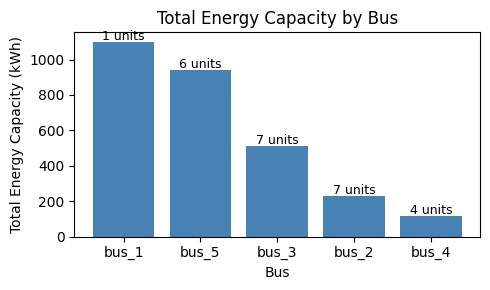

In [79]:
# Bar chart — Total energy capacity by bus
plt.figure(figsize=(5, 3))
bars = plt.bar(total_by_bus["Bus"], total_by_bus["Total Energy Capacity (kWh)"], color="steelblue")
plt.title("Total Energy Capacity by Bus")
plt.xlabel("Bus")
plt.ylabel("Total Energy Capacity (kWh)")

# Add number of units as label on each bar
for bar, units in zip(bars, avg_efficiency["Number of Units"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{units} units",
        ha="center", fontsize=9
    )

plt.tight_layout()
plt.show()